In [7]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load Data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Baseline Decision Tree
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
)

# Train Model
dt.fit(X_train, y_train)

# Predictions
train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

# In-Sample Performance
print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train, train_pred))
print("Precision:", precision_score(y_train, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, train_pred, average='weighted'))

# Out-of-Sample Performance
print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.48135377611140867
Precision: 0.5822155326681137
Recall   : 0.48135377611140867
F1 Score : 0.5021789512394096

Classification Report
              precision    recall  f1-score   support

           0       0.32      0.23      0.27      1525
           1       0.05      0.19      0.08      1667
           2       0.19      0.43      0.27      1040
           3       0.41      0.33      0.37      1012
           4       0.55      0.13      0.21      4827
           5       0.13      0.18      0.15      1388
           6       0.50      0.16      0.24      1231
           7       0.74      0.69      0.71     17182

    accuracy                           0.48     29872
   macro avg       0.36      0.29      0.29     29872
weighted avg       0.58      0.48      0.50     29872



In [3]:
print("Tree Depth :", dt.get_depth())
print("Number of Leaves :", dt.get_n_leaves())

Tree Depth : 30
Number of Leaves : 512


In [11]:
print("Maximum Depth:", dt.tree_.max_depth)
print("Number of Nodes:", dt.tree_.node_count)
print("Number of Leaves:", dt.get_n_leaves())

Maximum Depth: 30
Number of Nodes: 1023
Number of Leaves: 512


In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 80-20 Split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sub, y_train_sub)

print("Best Parameters:")
print(grid_search.best_params_)

best_dt = grid_search.best_estimator_

Fitting 3 folds for each of 90 candidates, totalling 270 fits
Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [9]:
print("Tuned Tree Depth:", best_dt.get_depth())
print("Number of Leaves:", best_dt.get_n_leaves())

Tuned Tree Depth: 25
Number of Leaves: 417


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
train_pred = best_dt.predict(X_train_sub)
test_pred = best_dt.predict(X_test)

print("="*50)
print("IN-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_train_sub, train_pred))
print("Precision:", precision_score(y_train_sub, train_pred, average='weighted'))
print("Recall   :", recall_score(y_train_sub, train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train_sub, train_pred, average='weighted'))

print("\n" + "="*50)
print("OUT-OF-SAMPLE PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, test_pred, average='weighted'))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

IN-SAMPLE PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

OUT-OF-SAMPLE PERFORMANCE
Accuracy : 0.598821638993037
Precision: 0.5906463208783216
Recall   : 0.598821638993037
F1 Score : 0.5625697657824831

Classification Report
              precision    recall  f1-score   support

           0       0.36      0.23      0.28      1525
           1       0.15      0.17      0.16      1667
           2       0.27      0.43      0.33      1040
           3       0.46      0.32      0.38      1012
           4       0.66      0.17      0.26      4827
           5       0.18      0.19      0.19      1388
           6       0.33      0.17      0.23      1231
           7       0.71      0.88      0.79     17182

    accuracy                           0.60     29872
   macro avg       0.39      0.32      0.33     29872
weighted avg       0.59      0.60      0.56     29872



In [8]:
comparison = pd.DataFrame({
    "Model": ["Baseline DT", "Tuned DT"],
    "Accuracy": [
        accuracy_score(y_test, dt.predict(X_test)),
        accuracy_score(y_test, best_dt.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, dt.predict(X_test), average='weighted'),
        precision_score(y_test, best_dt.predict(X_test), average='weighted')
    ],
    "Recall": [
        recall_score(y_test, dt.predict(X_test), average='weighted'),
        recall_score(y_test, best_dt.predict(X_test), average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, dt.predict(X_test), average='weighted'),
        f1_score(y_test, best_dt.predict(X_test), average='weighted')
    ]
})

print(comparison.round(4))

         Model  Accuracy  Precision  Recall  F1 Score
0  Baseline DT    0.4814     0.5822  0.4814    0.5022
1     Tuned DT    0.5988     0.5906  0.5988    0.5626


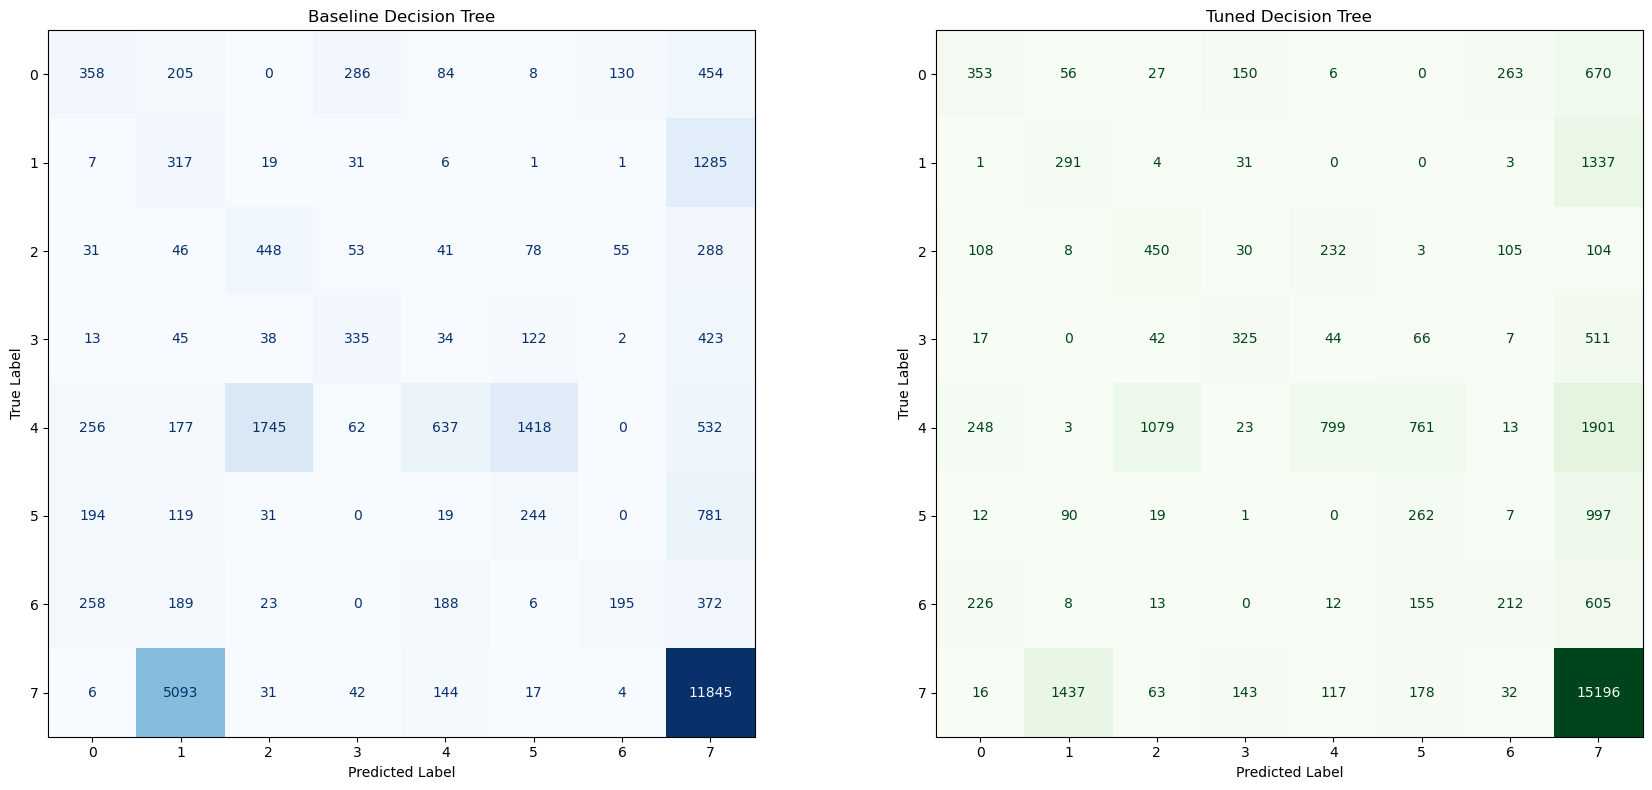

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = dt.predict(X_test)
tuned_pred = best_dt.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=dt.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline Decision Tree")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Tuned Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_dt.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned Decision Tree")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = dt.predict(X_test)
tuned_pred = best_dt.predict(X_test)

# Classification Reports
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        baseline_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

tuned_report = pd.DataFrame(
    classification_report(
        y_test,
        tuned_pred,
        output_dict=True,
        zero_division=0
    )
).transpose()

precision_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[
        baseline_report.index[:-3], "precision"
    ].values,
    "Tuned Precision": tuned_report.loc[
        tuned_report.index[:-3], "precision"
    ].values
})

precision_table = precision_table.round(4)

print("Precision Comparison")
display(precision_table)



recall_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[
        baseline_report.index[:-3], "recall"
    ].values,
    "Tuned Recall": tuned_report.loc[
        tuned_report.index[:-3], "recall"
    ].values
})

recall_table = recall_table.round(4)

print("Recall Comparison")
display(recall_table)

f1_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[
        baseline_report.index[:-3], "f1-score"
    ].values,
    "Tuned F1-Score": tuned_report.loc[
        tuned_report.index[:-3], "f1-score"
    ].values
})

f1_table = f1_table.round(4)

print("F1-Score Comparison")
display(f1_table)

import numpy as np
from sklearn.metrics import accuracy_score

classes = np.unique(y_test)

accuracy_list = []

for cls in classes:

    y_true_binary = (y_test == cls).astype(int)

    baseline_binary = (baseline_pred == cls).astype(int)
    tuned_binary = (tuned_pred == cls).astype(int)

    accuracy_list.append([
        cls,
        accuracy_score(y_true_binary, baseline_binary),
        accuracy_score(y_true_binary, tuned_binary)
    ])

accuracy_table = pd.DataFrame(
    accuracy_list,
    columns=[
        "Class",
        "Baseline Accuracy",
        "Tuned Accuracy"
    ]
)

accuracy_table = accuracy_table.round(4)

print("Individual Class Accuracy")
display(accuracy_table)

comparison_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],

    "Baseline Precision":
        baseline_report.loc[
            baseline_report.index[:-3],
            "precision"
        ].values,

    "Tuned Precision":
        tuned_report.loc[
            tuned_report.index[:-3],
            "precision"
        ].values,

    "Baseline Recall":
        baseline_report.loc[
            baseline_report.index[:-3],
            "recall"
        ].values,

    "Tuned Recall":
        tuned_report.loc[
            tuned_report.index[:-3],
            "recall"
        ].values,

    "Baseline F1":
        baseline_report.loc[
            baseline_report.index[:-3],
            "f1-score"
        ].values,

    "Tuned F1":
        tuned_report.loc[
            tuned_report.index[:-3],
            "f1-score"
        ].values,

    "Baseline Accuracy":
        accuracy_table["Baseline Accuracy"],

    "Tuned Accuracy":
        accuracy_table["Tuned Accuracy"]
})

comparison_table = comparison_table.round(4)

print("Decision Tree: Baseline vs Tuned")
display(comparison_table)

Precision Comparison


,Class,Baseline Precision,Tuned Precision
0,0,0.3188,0.3598
1,1,0.0512,0.1537
2,2,0.1919,0.2652
3,3,0.4141,0.4623
4,4,0.5525,0.6603
5,5,0.1288,0.1839
6,6,0.5039,0.3302
7,7,0.7412,0.7127


Recall Comparison


,Class,Baseline Recall,Tuned Recall
0,0,0.2348,0.2315
1,1,0.1902,0.1746
2,2,0.4308,0.4327
3,3,0.3310,0.3211
4,4,0.1320,0.1655
5,5,0.1758,0.1888
6,6,0.1584,0.1722
7,7,0.6894,0.8844


F1-Score Comparison


,Class,Baseline F1-Score,Tuned F1-Score
0,0,0.2704,0.2817
1,1,0.0807,0.1635
2,2,0.2655,0.3288
3,3,0.3679,0.3790
4,4,0.2130,0.2647
5,5,0.1487,0.1863
6,6,0.2410,0.2264
7,7,0.7144,0.7893


Individual Class Accuracy


,Class,Baseline Accuracy,Tuned Accuracy
0,0,0.9353,0.9397
1,1,0.7582,0.9003
2,2,0.9170,0.9385
3,3,0.9615,0.9643
4,4,0.8425,0.8514
5,5,0.9065,0.9234
6,6,0.9589,0.9515
7,7,0.6829,0.7285


Decision Tree: Baseline vs Tuned


,Class,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline Accuracy,Tuned Accuracy
0,0,0.3188,0.3598,0.2348,0.2315,0.2704,0.2817,0.9353,0.9397
1,1,0.0512,0.1537,0.1902,0.1746,0.0807,0.1635,0.7582,0.9003
2,2,0.1919,0.2652,0.4308,0.4327,0.2655,0.3288,0.9170,0.9385
3,3,0.4141,0.4623,0.3310,0.3211,0.3679,0.3790,0.9615,0.9643
4,4,0.5525,0.6603,0.1320,0.1655,0.2130,0.2647,0.8425,0.8514
5,5,0.1288,0.1839,0.1758,0.1888,0.1487,0.1863,0.9065,0.9234
6,6,0.5039,0.3302,0.1584,0.1722,0.2410,0.2264,0.9589,0.9515
7,7,0.7412,0.7127,0.6894,0.8844,0.7144,0.7893,0.6829,0.7285


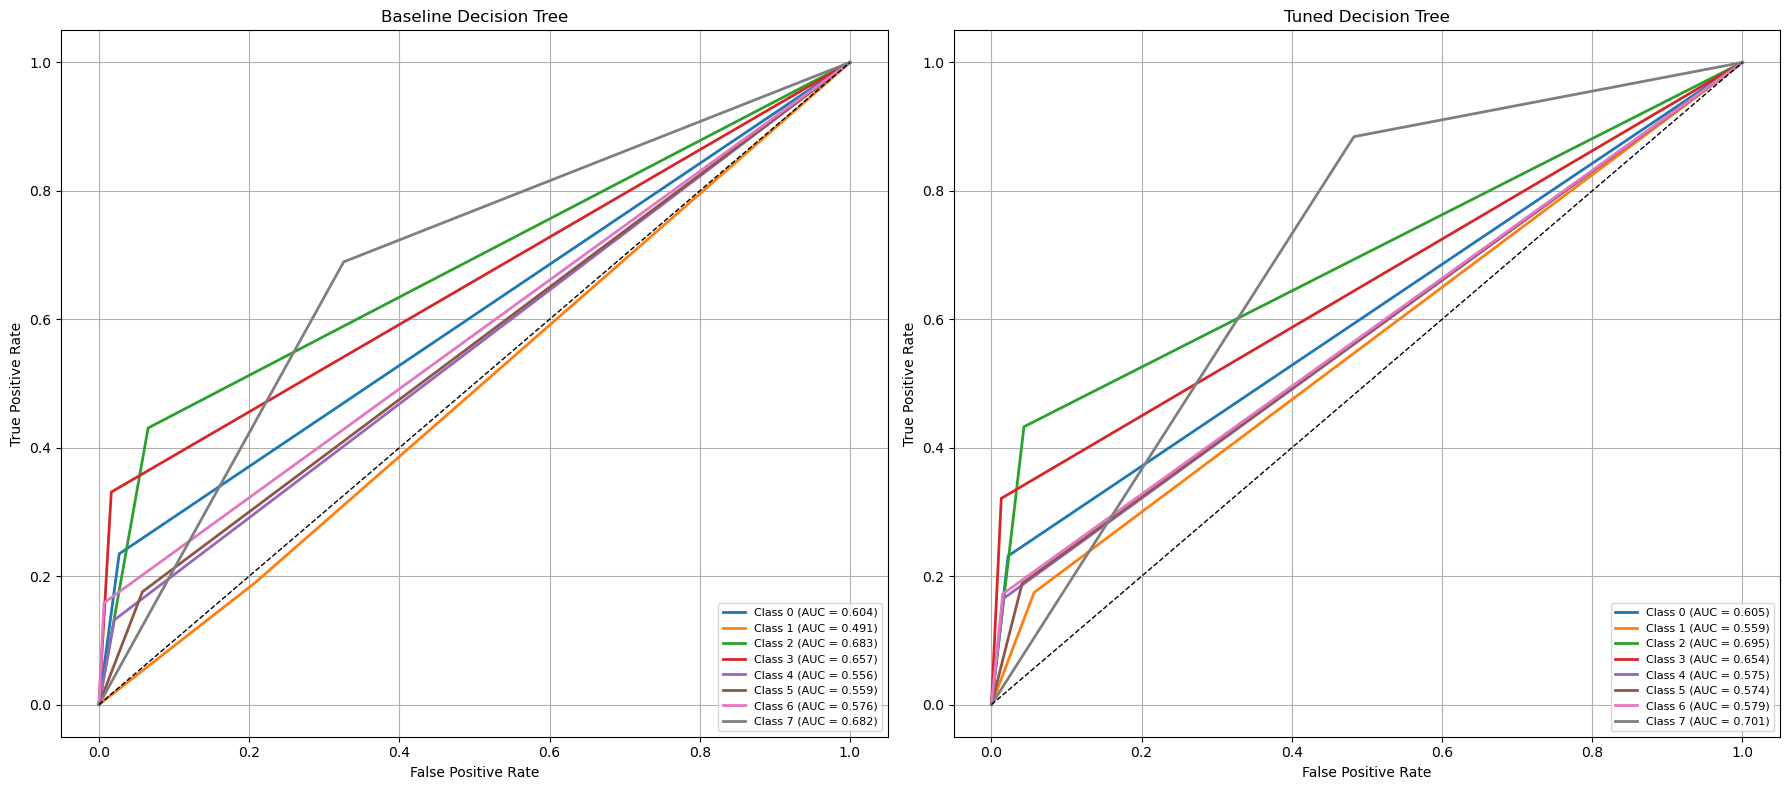

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = dt.predict_proba(X_test)
tuned_prob = best_dt.predict_proba(X_test)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --------------------------------------------------
# Baseline Decision Tree
# --------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], baseline_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title("Baseline Decision Tree")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)

# --------------------------------------------------
# Tuned Decision Tree
# --------------------------------------------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], tuned_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Tuned Decision Tree")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

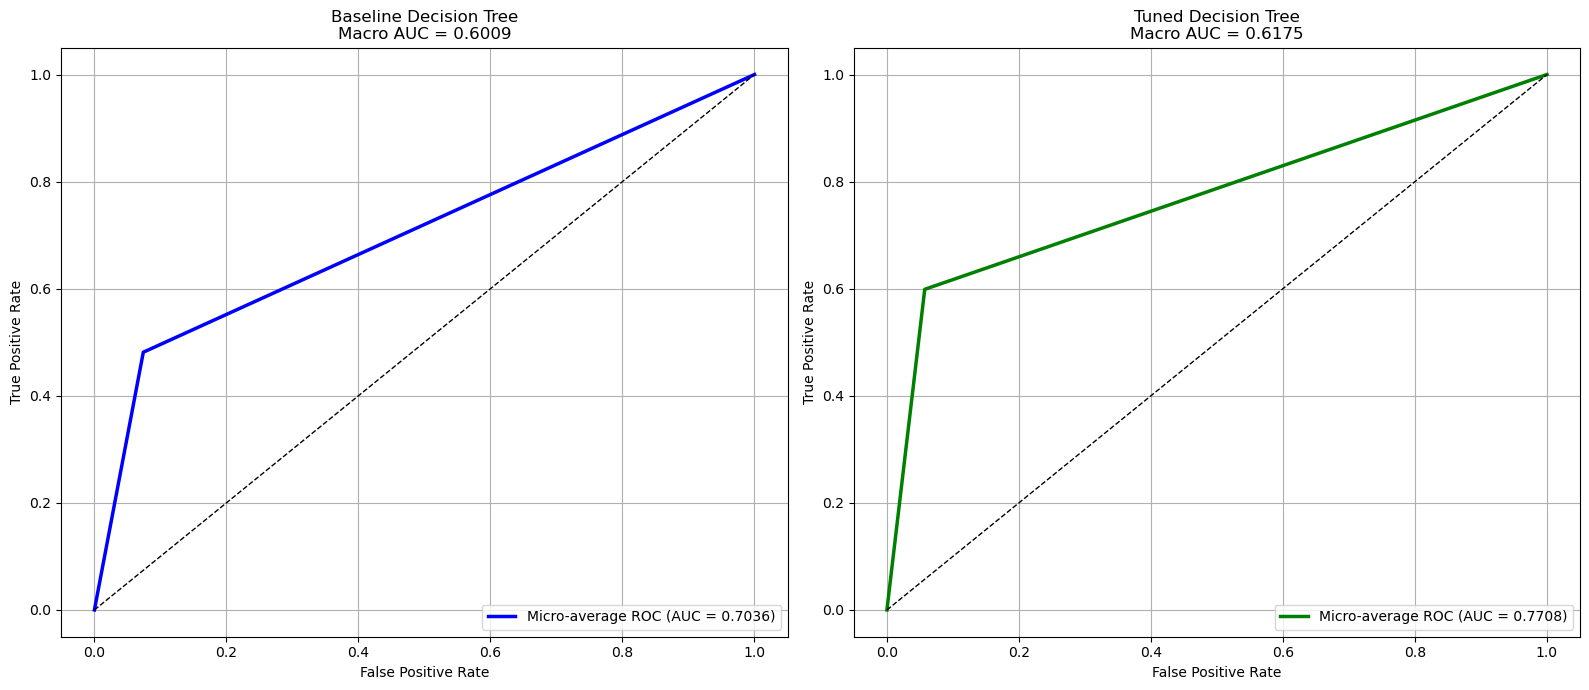

In [17]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Classes
classes = np.unique(y_test)

# Binarize the labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = dt.predict_proba(X_test)
tuned_prob = best_dt.predict_proba(X_test)

# --------------------------------------------------
# Baseline Decision Tree
# --------------------------------------------------
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin.ravel(),
    baseline_prob.ravel()
)

micro_auc_base = auc(fpr_base, tpr_base)

macro_auc_base = roc_auc_score(
    y_test_bin,
    baseline_prob,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Tuned Decision Tree
# --------------------------------------------------
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test_bin.ravel(),
    tuned_prob.ravel()
)

micro_auc_tuned = auc(fpr_tuned, tpr_tuned)

macro_auc_tuned = roc_auc_score(
    y_test_bin,
    tuned_prob,
    average='macro',
    multi_class='ovr'
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline
axes[0].plot(
    fpr_base,
    tpr_base,
    color='blue',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_base:.4f})"
)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[0].set_title(
    f"Baseline Decision Tree\nMacro AUC = {macro_auc_base:.4f}"
)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Tuned
axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    color='green',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_tuned:.4f})"
)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)

axes[1].set_title(
    f"Tuned Decision Tree\nMacro AUC = {macro_auc_tuned:.4f}"
)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()